### Linear Regression - Medical Insurance Data

In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [9]:
df = pd.read_csv("../../data/medical_insurance.csv")

In [10]:
df['gender'].replace({"male":1, "female":0}, inplace = True)
df['smoker'].replace({"yes":1, "no":0}, inplace = True)
df

,age,gender,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830
1334,18,0,31.920,0,0,northeast,2205.98080
1335,18,0,36.850,0,0,southeast,1629.83350
1336,21,0,25.800,0,0,southwest,2007.94500


In [11]:
df = pd.get_dummies(df, columns=['region'], dtype = int)
df

,age,gender,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,0,1,0,0
1334,18,0,31.920,0,0,2205.98080,1,0,0,0
1335,18,0,36.850,0,0,1629.83350,0,0,1,0
1336,21,0,25.800,0,0,2007.94500,0,0,0,1


### Train Test Split

In [12]:
x = df.drop("charges", axis = 1) # 2D
y = df['charges']

In [13]:
x.shape

(1338, 9)

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x,y, train_size=0.80, random_state = 23)
x_train

,age,gender,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
708,31,0,30.495,3,0,1,0,0,0
45,55,1,37.300,0,0,0,0,0,1
434,31,1,28.595,1,0,0,1,0,0
995,39,0,23.275,3,0,1,0,0,0
1299,19,0,25.745,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...
31,18,0,26.315,0,0,1,0,0,0
950,57,1,18.335,0,0,1,0,0,0
1064,29,0,25.600,4,0,0,0,0,1
742,53,1,34.105,0,1,1,0,0,0


In [15]:
y_train

708      6113.23105
45      20630.28351
434      4243.59005
995      7986.47525
1299     2710.82855
           ...     
31       2198.18985
950     11534.87265
1064     5708.86700
742     43254.41795
595      8823.98575
Name: charges, Length: 1070, dtype: float64

In [16]:
x_test

,age,gender,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
918,61,0,28.200,0,0,0,0,0,1
755,31,1,27.645,2,0,1,0,0,0
207,35,1,27.740,2,1,1,0,0,0
520,50,0,27.360,0,0,1,0,0,0
695,26,0,40.185,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...
298,31,1,34.390,3,1,0,1,0,0
369,18,1,30.400,3,0,1,0,0,0
153,42,0,23.370,0,1,1,0,0,0
264,53,0,38.060,3,0,0,0,1,0


In [17]:
y_test

918    13041.92100
755     5031.26955
207    20984.09360
520    25656.57526
695     3201.24515
          ...     
298    38746.35510
369     3481.86800
153    19964.74630
264    20462.99766
359     1607.51010
Name: charges, Length: 268, dtype: float64

### Model Training

In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
linear_reg = LinearRegression()
linear_reg.fit(x_train, y_train)

LinearRegression()

In [20]:
linear_reg.coef_

array([  244.58163948,   -93.04516525,   338.44461198,   511.86943511,
       24000.54812419,   819.80610551,   274.23818994,  -418.87774376,
        -675.16655168])

In [21]:
linear_reg.intercept_

-12094.5207136322

### Model Evaluation

In [22]:
x_test[100:105]

,age,gender,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
9,60,0,25.840,0,0,0,1,0,0
993,38,1,28.270,1,0,0,0,1,0
926,19,0,23.400,2,0,0,0,0,1
527,51,0,25.800,1,0,0,0,0,1
26,63,0,23.085,0,0,1,0,0,0


In [23]:
y_pred_test = linear_reg.predict(x_test)
y_pred_test[100:105] # Predicted Values

array([11600.02461858,  6767.35729329,   820.70667529,  8947.71677227,
       11946.92254659])

In [24]:
y_test[100:105] # Actual

9      28923.13692
993     5484.46730
926     2913.56900
527     9861.02500
26     14451.83515
Name: charges, dtype: float64

In [25]:
y_test.shape

(268,)

In [26]:
y_test

918    13041.92100
755     5031.26955
207    20984.09360
520    25656.57526
695     3201.24515
          ...     
298    38746.35510
369     3481.86800
153    19964.74630
264    20462.99766
359     1607.51010
Name: charges, Length: 268, dtype: float64

In [27]:
error = y_test - y_pred_test
error

918     1347.990199
755    -1563.041669
207   -10621.244539
520    15442.363310
695    -4937.991685
           ...     
298     5902.385330
369    -1377.166247
153   -10942.966656
264     5596.758988
359     2682.175564
Name: charges, Length: 268, dtype: float64

In [28]:
y_test.size

268

In [29]:
(error ** 2).sum()

9286750171.681465

In [30]:
mse = ((error ** 2).sum())/y_test.size
mse

34652052.87940845

In [31]:
rmse = np.sqrt(((error ** 2).sum())/y_test.size)
rmse

5886.599432559383

In [32]:
mse = mean_squared_error(y_test, y_pred_test)
mse

34652052.87940845

In [33]:
mae = mean_absolute_error(y_test, y_pred_test)
mae

3991.20379351366

#### Training data evaluation

In [34]:
x_train.head(2)

,age,gender,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest
708,31,0,30.495,3,0,1,0,0,0
45,55,1,37.300,0,0,0,0,0,1


In [35]:
y_pred_train = linear_reg.predict(x_train)
y_pred_train.size

1070

In [36]:
mse = mean_squared_error(y_train, y_pred_train)
mse

37056761.48533833

In [37]:
rmse = np.sqrt(mse)
rmse

6087.426507592378

#### R-squared Error

In [38]:
r2_train = r2_score(y_train, y_pred_train)
r2_train

0.7493255146273343

In [39]:
r2_test = r2_score(y_test, y_pred_test)
r2_test

0.7536440382001556

### Training Data Evaluation

In [40]:
y_pred_train = linear_reg.predict(x_train)

mse = mean_squared_error(y_train, y_pred_train)
print("MSE :",mse)

rmse = np.sqrt(mse)
print("RMSE :",rmse)

mae = mean_absolute_error(y_train, y_pred_train)
print("MAE :",mae)

r2_train = r2_score(y_train, y_pred_train)
print("R-squared :",r2_train)

MSE : 37056761.48533833
RMSE : 6087.426507592378
MAE : 4212.153489540199
R-squared : 0.7493255146273343


In [41]:
y_train

708      6113.23105
45      20630.28351
434      4243.59005
995      7986.47525
1299     2710.82855
           ...     
31       2198.18985
950     11534.87265
1064     5708.86700
742     43254.41795
595      8823.98575
Name: charges, Length: 1070, dtype: float64

In [42]:
pd.Series(y_pred_train)

0        8163.792963
1       13213.241768
2        5858.396250
3        7676.875981
4        2051.894597
            ...     
1065     2033.924867
1066     8778.775638
1067     5034.840087
1068    37138.268735
1069    11901.954782
Length: 1070, dtype: float64

In [43]:
error = y_train - y_pred_train
error

708    -2050.561913
45      7417.041742
434    -1614.806200
995      309.599269
1299     658.933953
           ...     
31       164.264983
950     2756.097012
1064     674.026913
742     6116.149215
595    -3077.969032
Name: charges, Length: 1070, dtype: float64

#### Testing data evaluation

In [44]:
y_pred_test = linear_reg.predict(x_test)

mse = mean_squared_error(y_test, y_pred_test)
print("MSE :",mse)

rmse = np.sqrt(mse)
print("RMSE :",rmse)

mae = mean_absolute_error(y_test, y_pred_test)
print("MAE :",mae)

r2_test = r2_score(y_test, y_pred_test)
print("R-squared :",r2_test)

MSE : 34652052.87940845
RMSE : 5886.599432559383
MAE : 3991.20379351366
R-squared : 0.7536440382001556


### Save model

In [45]:
import pickle
with open("linear_reg_med_ins.pkl", "wb") as f:
    pickle.dump(linear_reg, f)

In [46]:
R2 = 0.9
VIF = 1/(1-R2)
VIF

10.000000000000002

In [47]:
R2 = 0
VIF = 1/(1-R2)
VIF

1.0

In [48]:
R2 = 0.2
VIF = 1/(1-R2)
VIF

1.25

In [49]:
R2 = 0.5
VIF = 1/(1-R2)
VIF

2.0

In [50]:
R2 = 0.7
VIF = 1/(1-R2)
VIF

3.333333333333333

In [51]:
R2 = 0.99
VIF = 1/(1-R2)
VIF

99.99999999999991

In [52]:
R2 = 0.987654
VIF = 1/(1-R2)
VIF

80.99789405475478

### Normality of Residual

In [53]:
error = y_test - y_pred_test
error

918     1347.990199
755    -1563.041669
207   -10621.244539
520    15442.363310
695    -4937.991685
           ...     
298     5902.385330
369    -1377.166247
153   -10942.966656
264     5596.758988
359     2682.175564
Name: charges, Length: 268, dtype: float64

In [54]:
error = y_train - y_pred_train
error

708    -2050.561913
45      7417.041742
434    -1614.806200
995      309.599269
1299     658.933953
           ...     
31       164.264983
950     2756.097012
1064     674.026913
742     6116.149215
595    -3077.969032
Name: charges, Length: 1070, dtype: float64

<AxesSubplot:xlabel='charges', ylabel='Count'>

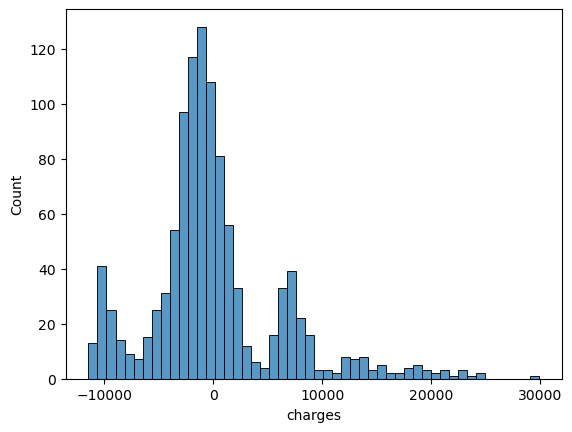

In [55]:
sns.histplot(error)

<AxesSubplot:xlabel='charges', ylabel='Count'>

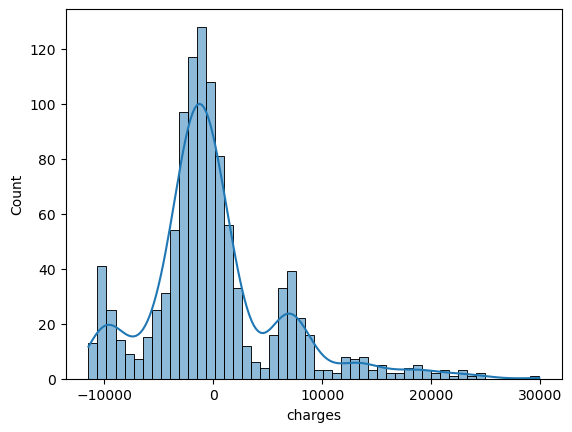

In [56]:
sns.histplot(error, kde = True)

<AxesSubplot:xlabel='charges', ylabel='Density'>

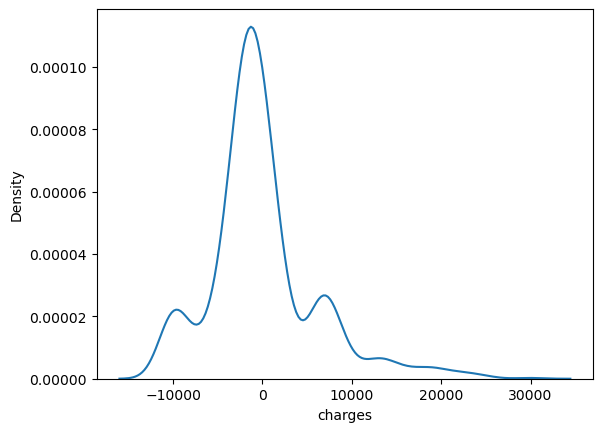

In [57]:
sns.kdeplot(error)

In [58]:
error.skew()

1.1844031564650432

### Hypothesis Testing

In [59]:
from scipy.stats import shapiro, normaltest, kstest

In [60]:
stats, p_val = shapiro(error)
print("p value :", p_val)
if p_val >= 0.05:
    print("Data is normally distributed")

else:
    print("data is not normally distributed")

p value : 1.8321990605998363e-25
data is not normally distributed


p value : 0.5389614852314664
Data is normally distributed


<AxesSubplot:ylabel='Density'>

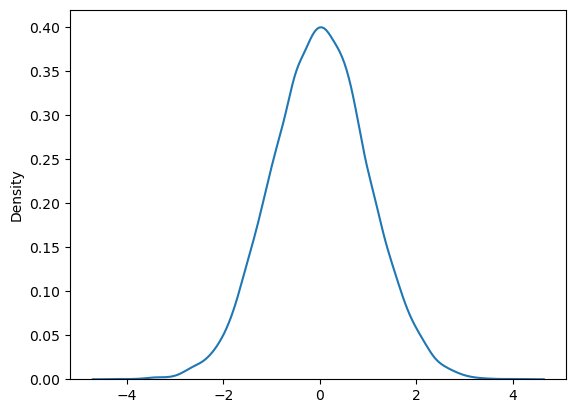

In [61]:
array = np.random.randn(15000)

stats, p_val = shapiro(array)
print("p value :", p_val)
if p_val >= 0.05:
    print("Data is normally distributed")

else:
    print("data is not normally distributed")

sns.kdeplot(array)

p value : 0.5456810328212195
Data is normally distributed


<AxesSubplot:ylabel='Density'>

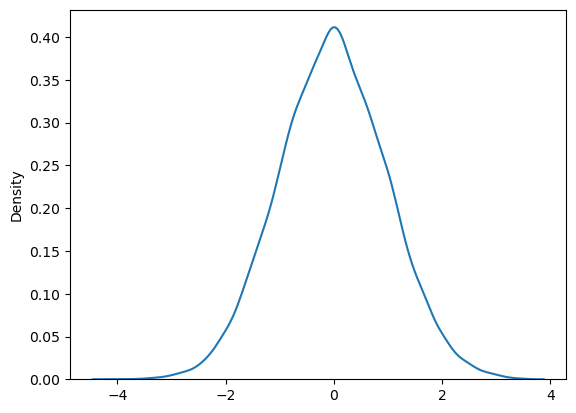

In [62]:
array = np.random.randn(15000)

stats, p_val = normaltest(array)
print("p value :", p_val)
if p_val >= 0.05:
    print("Data is normally distributed")

else:
    print("data is not normally distributed")

sns.kdeplot(array)

In [63]:
# array = np.random.randn(15000)

stats, p_val = normaltest(error)
print("p value :", p_val)
if p_val >= 0.05:
    print("Data is normally distributed")

else:
    print("data is not normally distributed")

# sns.kdeplot(array)

p value : 7.210354841113296e-52
data is not normally distributed


In [64]:
stats, p_val = kstest(error, 'norm')
print("p value :", p_val)
if p_val >= 0.05:
    print("Data is normally distributed")

else:
    print("data is not normally distributed")

p value : 0.0
data is not normally distributed


### QQplot

In [65]:
from scipy.stats import probplot

In [66]:
import statsmodels.api as sm

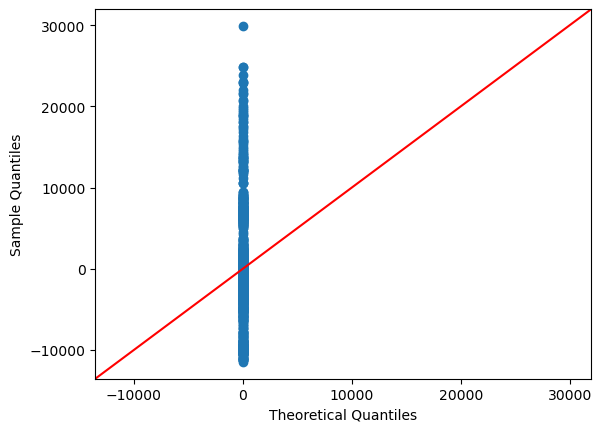

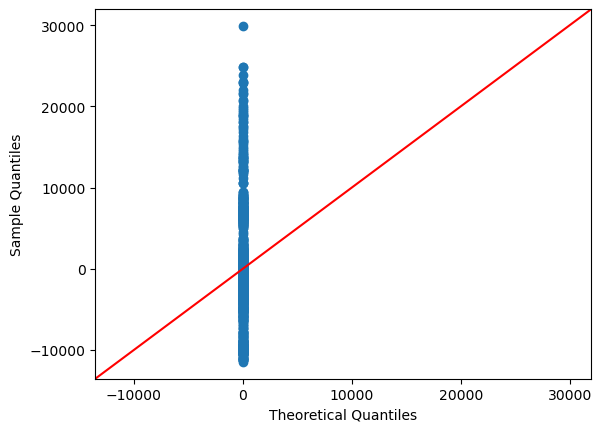

In [67]:
sm.qqplot(error, line = '45')

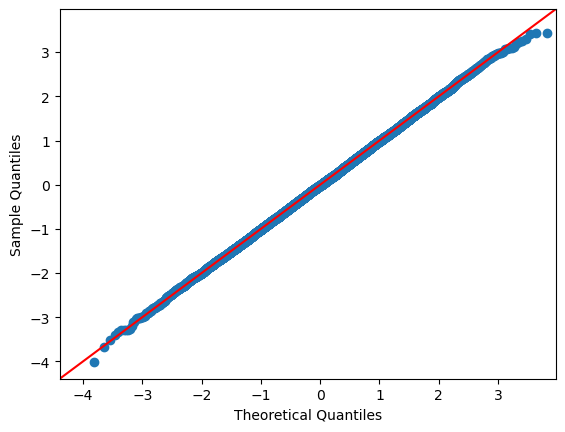

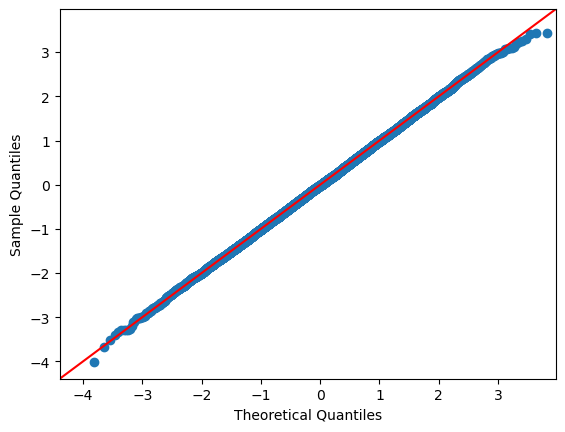

In [68]:
sm.qqplot(array, line = '45')

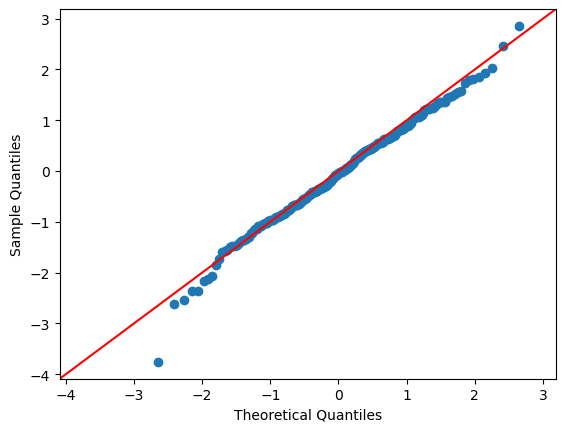

In [69]:
array = np.random.randn(250)
sm.qqplot(array, line = '45')
plt.savefig("QQPlot.png")

### 4. Homoscedasticity

In [70]:
y_pred_train

array([ 8163.79296333, 13213.24176757,  5858.39624953, ...,
        5034.84008666, 37138.26873472, 11901.95478199])

In [71]:
error

708    -2050.561913
45      7417.041742
434    -1614.806200
995      309.599269
1299     658.933953
           ...     
31       164.264983
950     2756.097012
1064     674.026913
742     6116.149215
595    -3077.969032
Name: charges, Length: 1070, dtype: float64

<AxesSubplot:ylabel='charges'>

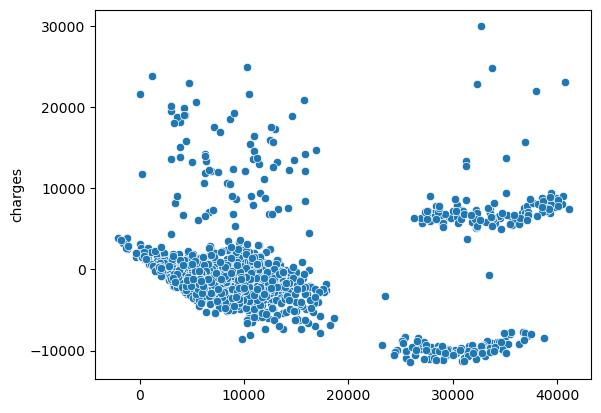

In [72]:
sns.scatterplot(x = y_pred_train,y=  error)

### Save Columns Data

In [73]:
import json

In [74]:
df['gender'].replace({"male":1, "female":0}, inplace = True)
df['smoker'].replace({"yes":1, "no":0}, inplace = True)
df

,age,gender,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,0,1,0,0
1334,18,0,31.920,0,0,2205.98080,1,0,0,0
1335,18,0,36.850,0,0,1629.83350,0,0,1,0
1336,21,0,25.800,0,0,2007.94500,0,0,0,1


In [75]:
med_ins_json = {"gender" : {"male":1, "female":0},
                "smoker" : {"yes":1, "no":0}, 
               "colName" : list(linear_reg.feature_names_in_)}
med_ins_json

{'gender': {'male': 1, 'female': 0},
 'smoker': {'yes': 1, 'no': 0},
 'colName': ['age',
  'gender',
  'bmi',
  'children',
  'smoker',
  'region_northeast',
  'region_northwest',
  'region_southeast',
  'region_southwest']}

In [76]:
with open("med_ins_column_data.json", "w") as f:
    json.dump(med_ins_json, f)

In [77]:
linear_reg.feature_names_in_

array(['age', 'gender', 'bmi', 'children', 'smoker', 'region_northeast',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype=object)

In [78]:
linear_reg.n_features_in_

9